# Per-Letter Reference Sheets

Builds two things from the pseudo-labels, both from data already in the repo:

1. **`letter_sheets/<letter>.png`** — every occurrence of one letter, side by side, drawn from
   different words and different signers.
2. **`letter_sheets/_alphabet.png`** — one clean exemplar per letter, i.e. a PSL fingerspelling
   reference derived from this dataset rather than an external source.

### Why this is the right verification step

The per-clip sheets in `spot_check/` ask *"is segment i really letter i?"*, which needs someone
who knows PSL handshapes. These sheets ask a much weaker question that anyone can answer:

> **Do the images in this row look like the same handshape?**

If the pseudo-labels are sound, each sheet is visibly self-similar — the same pose from
different people in different words. If they are noise, a sheet is an obvious grab-bag. No
knowledge of Urdu or PSL is needed to tell those apart.

This is also the visual counterpart of the numerical result in `letter_classifier.ipynb`, where
1-NN letter retrieval ran at 8.9 % against 5.4 % chance. That number is consistent with two very
different stories — labels are noise, or the *features* fail to capture handshape while the
labels are fine. **Looking at the images distinguishes them**, and nothing else we have does.

### Second use

`_alphabet.png` doubles as something to imitate when testing the live demo. Segmentation does
not care whether a pose is a real PSL letter — it detects pauses in motion — but copying real
handshapes at the dataset's own rhythm (~2 letters/second, median 0.40 s apart) makes the live
test a much closer match to the conditions the method was tuned for.

## Setup

In [1]:
import json
import os
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# DejaVu Sans has no Arabic glyphs, so captions would render as boxes. Pick a
# font by TESTING coverage of the actual letters rather than by name -- an
# earlier guess picked Nirmala UI, which sounds plausible but is an Indic font
# with no Arabic at all. Single isolated letters need no bidi/reshaping.
from fontTools.ttLib import TTFont

_needed = {ord(l) for v in json.load(open("word_letter_mapping.json", encoding="utf-8")).values()
           for l in v}

def _covers(path):
    try:
        t = TTFont(path, fontNumber=0, lazy=True)
        cmap = set()
        for tb in t["cmap"].tables:
            cmap |= set(tb.cmap.keys())
        t.close()
        return _needed <= cmap
    except Exception:
        return False

_seen, _chosen = set(), None
for _f in font_manager.fontManager.ttflist:
    if _f.name in _seen:
        continue
    _seen.add(_f.name)
    if _covers(_f.fname):
        _chosen = _f.name
        break
if _chosen:
    plt.rcParams["font.family"] = _chosen
print(f"caption font: {_chosen or 'NONE FOUND - captions will show boxes'} "
      f"({len(_needed)} codepoints required)")

VIDEO_ROOT = "PSL_Fingerspelling_Video_Dataset_Cropped/PSL_Fingerspelling_Video_Dataset_Cropped"
OUT = "letter_sheets"
os.makedirs(OUT, exist_ok=True)

segments = pd.read_csv("pseudo_label_segments.csv")
clips = pd.read_csv("pseudo_label_clips.csv")

seg = segments.merge(
    clips[["signer_id", "video_id", "mean_pick_depth", "alignment_confidence",
           "constraint_dominated"]],
    on=["signer_id", "video_id"])
print(f"{len(seg)} letter occurrences, {seg.letter.nunique()} distinct letters")

caption font: Segoe UI (40 codepoints required)
1366 letter occurrences, 40 distinct letters


## Rank occurrences by how much we trust them

Sheets show the most trustworthy examples first, so a sheet that still looks inconsistent at
the top is real evidence of a problem rather than an artefact of picking bad clips.

`constraint_dominated` clips (where the alignment DP tiled the clip instead of finding troughs)
are pushed to the end — they are known-bad and are labelled as such on the sheet.

In [2]:
seg["trust"] = (seg.alignment_confidence
                - 0.6 * seg.mean_pick_depth
                - 1.0 * seg.constraint_dominated.astype(float))
seg = seg.sort_values("trust", ascending=False)

MAX_PER_SHEET = 15
picks = defaultdict(list)
for r in seg.itertuples():
    if len(picks[r.letter]) < MAX_PER_SHEET:
        picks[r.letter].append(r)

counts = {k: len(v) for k, v in picks.items()}
print(f"letters: {len(picks)}   examples per sheet: "
      f"min {min(counts.values())}, median {int(np.median(list(counts.values())))}, "
      f"max {max(counts.values())}")

letters: 40   examples per sheet: min 4, median 14, max 15


## Read the frames

Grouped by clip so each video file is opened once rather than once per frame.

In [3]:
need = defaultdict(list)          # (signer, video) -> [(letter, frame, idx_in_sheet)]
for letter, rows in picks.items():
    for i, r in enumerate(rows):
        need[(r.signer_id, r.video_id)].append((letter, int(r.minimum_frame), i, r))

frames = {}                       # (letter, i) -> BGR crop
missing = 0
for (sg, vid), items in need.items():
    cap = cv2.VideoCapture(os.path.join(VIDEO_ROOT, sg, vid))
    if not cap.isOpened():
        missing += len(items)
        continue
    for letter, f, i, r in sorted(items, key=lambda t: t[1]):
        cap.set(cv2.CAP_PROP_POS_FRAMES, f)
        ok, img = cap.read()
        if ok:
            frames[(letter, i)] = img
        else:
            missing += 1
    cap.release()

print(f"read {len(frames)} frames, {missing} unavailable")

read 466 frames, 0 unavailable


## One sheet per letter

In [4]:
def letter_sheet(letter, rows, path, ncol=5):
    imgs = [(i, r) for i, r in enumerate(rows) if (letter, i) in frames]
    if not imgs:
        return False
    n = len(imgs)
    ncol = min(ncol, n)
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(2.05 * ncol, 2.75 * nrow), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for k, (i, r) in enumerate(imgs):
        ax = axes[k // ncol][k % ncol]
        ax.imshow(cv2.cvtColor(frames[(letter, i)], cv2.COLOR_BGR2RGB))
        flag = "  [low-trust]" if r.constraint_dominated else ""
        ax.set_title(f"{r.signer_id.replace('signer','S')}  {r.spelling}\n"
                     f"pos {r.letter_index + 1}{flag}", fontsize=7.5)
    fig.suptitle(f"{letter}      ({len(rows)} occurrences shown)", fontsize=20)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig(path, dpi=80, bbox_inches="tight")
    plt.close(fig)
    return True

made = 0
for letter, rows in picks.items():
    # filenames use the codepoint: Urdu characters are not safe on all filesystems
    name = f"U{ord(letter):04X}_{letter}.png"
    if letter_sheet(letter, rows, os.path.join(OUT, name)):
        made += 1
print(f"wrote {made} per-letter sheets to {OUT}/")

wrote 40 per-letter sheets to letter_sheets/


## The alphabet overview

One exemplar per letter — the single most-trusted occurrence — laid out as a reference.

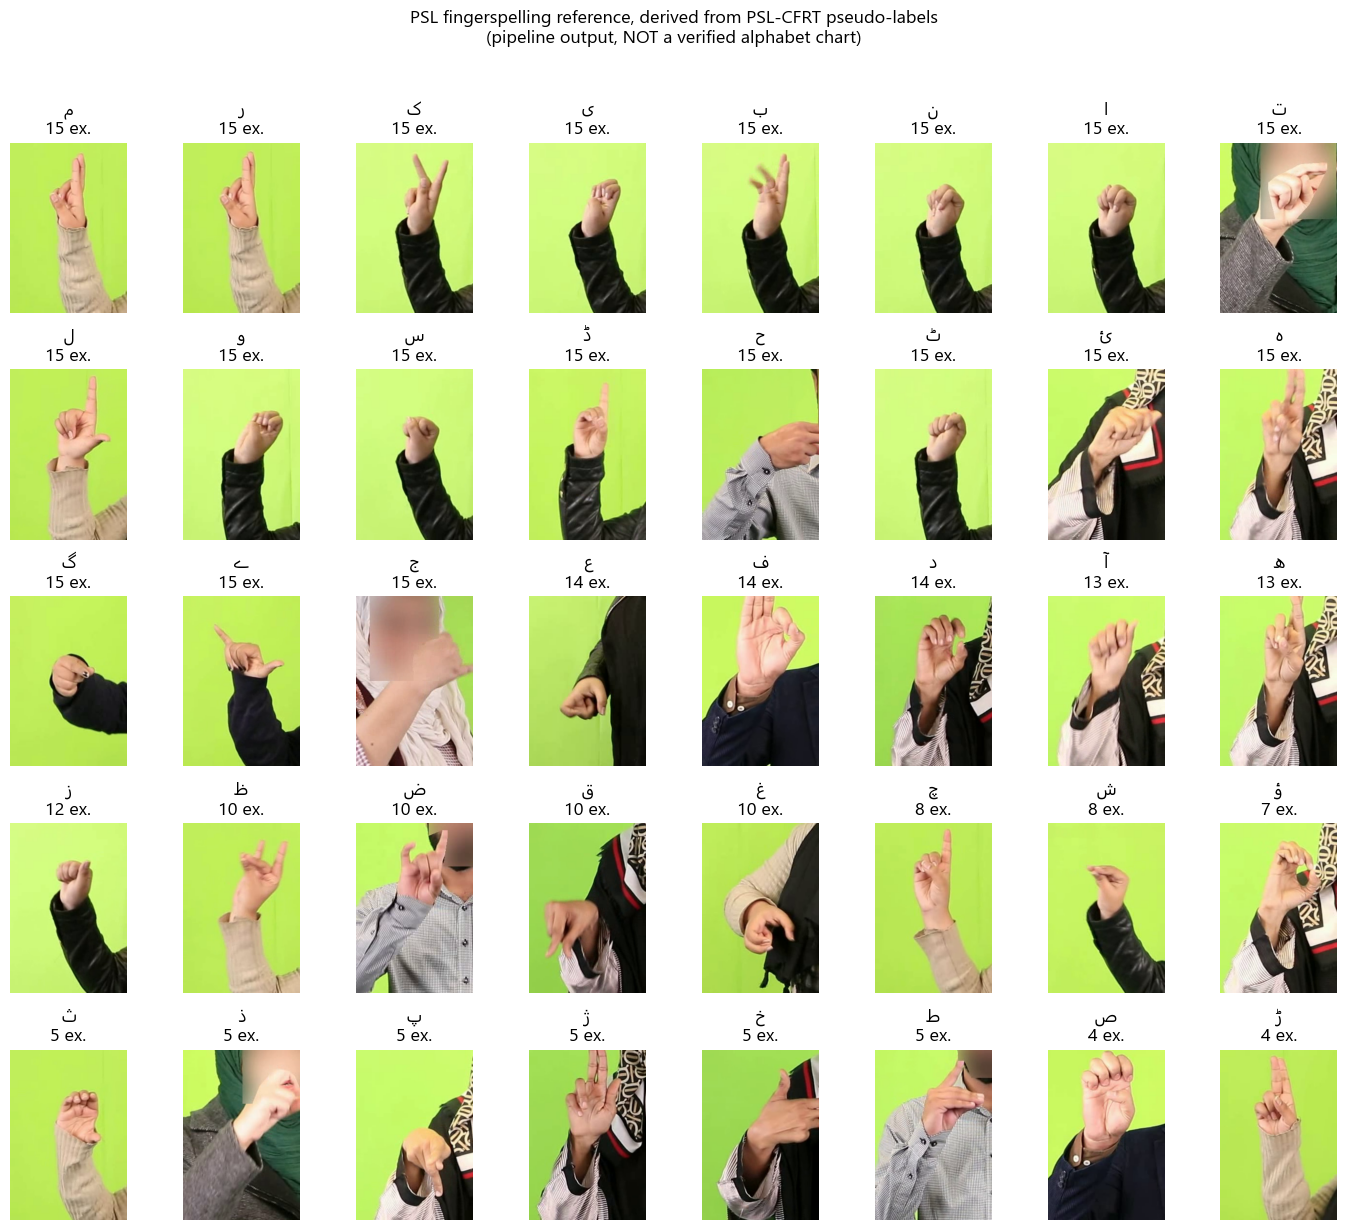

40 letters in the overview


In [5]:
best = {}
for letter, rows in picks.items():
    for i, r in enumerate(rows):
        if (letter, i) in frames and not r.constraint_dominated:
            best[letter] = (frames[(letter, i)], r)
            break
    if letter not in best and (letter, 0) in frames:
        best[letter] = (frames[(letter, 0)], rows[0])

order = sorted(best, key=lambda L: -len(picks[L]))    # commonest first
ncol = 8
nrow = int(np.ceil(len(order) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(1.75 * ncol, 2.5 * nrow), squeeze=False)
for ax in axes.ravel():
    ax.axis("off")
for k, letter in enumerate(order):
    img, r = best[letter]
    ax = axes[k // ncol][k % ncol]
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{letter}\n{len(picks[letter])} ex.", fontsize=13)
fig.suptitle("PSL fingerspelling reference, derived from PSL-CFRT pseudo-labels\n"
             "(pipeline output, NOT a verified alphabet chart)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(os.path.join(OUT, "_alphabet.png"), dpi=95, bbox_inches="tight")
plt.show()
print(f"{len(order)} letters in the overview")

**Read this with the right caution.** It is the pipeline's own output, not a verified
alphabet chart. If the pseudo-labels are wrong for some letter, this reproduces that error
confidently. It is a hypothesis to check against a real PSL source or a fluent signer — which
is exactly what the per-letter sheets are for.

## A numerical companion to the eyeball test

Looking at the sheets is the point, but one number helps decide where to look: how visually
self-consistent each letter is. Low-agreement letters are where to focus.

In [6]:
from letter_features import occurrence_table

df_feat = pd.read_csv("hand_keypoints_features.csv")
pl = pd.read_csv("pseudo_labels.csv")
X, meta = occurrence_table(pl, df_feat)

from sklearn.preprocessing import StandardScaler
Xz = StandardScaler().fit_transform(X)
letters = meta.letter.to_numpy()
clip_id = (meta.signer_id + "/" + meta.video_id).to_numpy()

D = ((Xz[:, None, :] - Xz[None, :, :]) ** 2).sum(-1)
np.fill_diagonal(D, np.inf)
D[clip_id[:, None] == clip_id[None, :]] = np.inf   # never match within a clip

rows = []
for L in sorted(set(letters)):
    m = letters == L
    if m.sum() < 2:
        continue
    within = D[np.ix_(m, m)]
    between = D[np.ix_(m, ~m)]
    rows.append({"letter": L, "n": int(m.sum()),
                 "median within": float(np.median(within[np.isfinite(within)])),
                 "median between": float(np.median(between[np.isfinite(between)]))})
cons = pd.DataFrame(rows)
cons["ratio"] = cons["median between"] / cons["median within"]
cons = cons.sort_values("ratio", ascending=False)
print("ratio > 1 means occurrences of this letter are closer to each other")
print("than to other letters -- higher is more self-consistent\n")
print(cons.round(2).to_string(index=False))

ratio > 1 means occurrences of this letter are closer to each other
than to other letters -- higher is more self-consistent

letter   n  median within  median between  ratio
     چ   8          20.75           39.61   1.91
     ژ   5          20.36           36.53   1.79
     ڈ  41          29.57           36.51   1.23
     گ  17          34.70           40.03   1.15
     و  78          34.17           39.08   1.14
     ض  10          38.51           42.60   1.11
     ن  98          37.43           40.26   1.08
     غ  10          39.62           42.60   1.08
     ی 106          37.63           40.04   1.06
     ئ  22          37.22           39.40   1.06
     ؤ   7          31.51           32.57   1.03
     ا 109          41.25           42.40   1.03
     ب  70          44.76           45.64   1.02
     ٹ  36          39.98           40.70   1.02
     ر 104          42.93           43.36   1.01
     ش   8          41.25           41.35   1.00
     ھ  13          39.38           39.30 

## How to use these

1. Open `letter_sheets/_alphabet.png` for the overview.
2. Open a few individual sheets, **starting with the highest-ratio letters** from the table
   above (most likely to be right) and then the **lowest-ratio** ones (most likely to be
   wrong). If the high-ratio sheets look self-consistent and the low-ratio ones look like a
   grab-bag, the ratio is a usable automatic proxy and the labels are broadly sound.
3. Note that the commonest letters have the most examples but also the most chances to be
   wrong; the singletons (ڑ خ ث پ ذ ط ص ژ) have ≤5 occurrences total in the entire corpus, so
   their sheets will be short no matter what.

**What a verdict here settles.** If the sheets look consistent, the pseudo-labels are fine and
`letter_classifier.ipynb`'s failure is definitively a *feature* problem — which makes the CNN on
hand crops the clearly correct next experiment. If they look inconsistent, the labelling needs
work first and a CNN would be trained on noise. That is a fork the whole project currently sits
on, and no amount of further offline metric-chasing resolves it.